In [1]:
import pandas as pd
import numpy as np

def load_carla(path):
    df = pd.read_csv(path)
    
    features = df[['accelX','accelY','accelZ',
                   'gyroX','gyroY','gyroZ']]
    return features.values


In [2]:
import os

def load_road_folder(folder):
    data = []

    for root, dirs, files in os.walk(folder):
        acc_file = None
        gyro_file = None

        for f in files:
            if 'Accelerometer' in f:
                acc_file = os.path.join(root, f)
            if 'Gyroscope' in f:
                gyro_file = os.path.join(root, f)

        if acc_file and gyro_file:
            acc = pd.read_csv(acc_file)
            gyro = pd.read_csv(gyro_file)

            # fix axis order: z,y,x → x,y,z
            acc_xyz = acc[['x','y','z']].values
            gyro_xyz = gyro[['x','y','z']].values

            min_len = min(len(acc_xyz), len(gyro_xyz))
            combined = np.hstack([
                acc_xyz[:min_len],
                gyro_xyz[:min_len]
            ])
            data.append(combined)

    return np.vstack(data)


In [3]:
carla = load_carla("data/carla/full_data_carla.csv")
road = load_road_folder("data/road")

all_data = np.vstack([carla, road])


In [4]:
def create_windows(data, window=60, stride=15):
    windows = []
    for i in range(0, len(data) - window, stride):
        windows.append(data[i:i+window])
    return np.array(windows)

windows = create_windows(all_data)
# Shape: (N, 60, 6)



In [5]:
mean = windows.mean(axis=(0,1))
std  = windows.std(axis=(0,1)) + 1e-8

windows = (windows - mean) / std

np.save("processed/mean.npy", mean)
np.save("processed/std.npy", std)

In [6]:
X = np.transpose(windows, (0,2,1))
X = X[..., np.newaxis]   # (N,6,60,1)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

def build_autoencoder():
    inp = Input(shape=(6,60,1))
    
    x = Conv2D(32, (3,3), padding="same", activation="relu")(inp)
    x = MaxPooling2D((1,2))(x)
    x = Dropout(0.2)(x)  # Dropout added

    x = Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = MaxPooling2D((1,2))(x)
    x = Dropout(0.2)(x)  # Dropout added

    x = Conv2D(64, (3,3), padding="same", activation="relu")(x)

    x = UpSampling2D((1,2))(x)
    x = Conv2D(64, (3,3), padding="same", activation="relu")(x)

    x = UpSampling2D((1,2))(x)
    x = Conv2D(32, (3,3), padding="same", activation="relu")(x)

    out = Conv2D(1, (3,3), padding="same")(x)

    model = Model(inp, out)
    model.compile(optimizer="adam", loss="mse")
    return model

model = build_autoencoder()
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 6, 60, 1)]        0         
                                                                 
 conv2d (Conv2D)             (None, 6, 60, 32)         320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 6, 30, 32)         0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 6, 30, 32)         0         
                                                                 
 conv2d_1 (Conv2D)           (None, 6, 30, 64)         18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 15, 64)         0         
 g2D)                                                        

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

In [10]:
history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=20,
    batch_size=64,
    shuffle=True,
    callbacks=[early_stop]
)

model.save("helmX_autoencoder.keras")

Epoch 1/20
349/349 [==============================] - 106s 286ms/step - loss: 0.1995 - val_loss: 0.0990
Epoch 2/20
349/349 [==============================] - 91s 261ms/step - loss: 0.1125 - val_loss: 0.0869
Epoch 3/20
349/349 [==============================] - 92s 263ms/step - loss: 0.1007 - val_loss: 0.0878
Epoch 4/20
349/349 [==============================] - 91s 262ms/step - loss: 0.0898 - val_loss: 0.0820
Epoch 5/20
349/349 [==============================] - 95s 272ms/step - loss: 0.0836 - val_loss: 0.0681
Epoch 6/20
349/349 [==============================] - 92s 264ms/step - loss: 0.0730 - val_loss: 0.0730
Epoch 7/20
349/349 [==============================] - 94s 270ms/step - loss: 0.0810 - val_loss: 0.1224
Epoch 8/20
349/349 [==============================] - 93s 266ms/step - loss: 0.0724 - val_loss: 0.0497
Epoch 9/20
349/349 [==============================] - 91s 262ms/step - loss: 0.0629 - val_loss: 0.0561
Epoch 10/20
349/349 [==============================] - 62s 176ms/step - 

In [11]:
recon = model.predict(X)
mse = np.mean((X - recon)**2, axis=(1,2,3))

threshold = mse.mean() + 3*mse.std()
np.save("processed/threshold.npy", threshold)

873/873 [==============================] - 23s 26ms/step


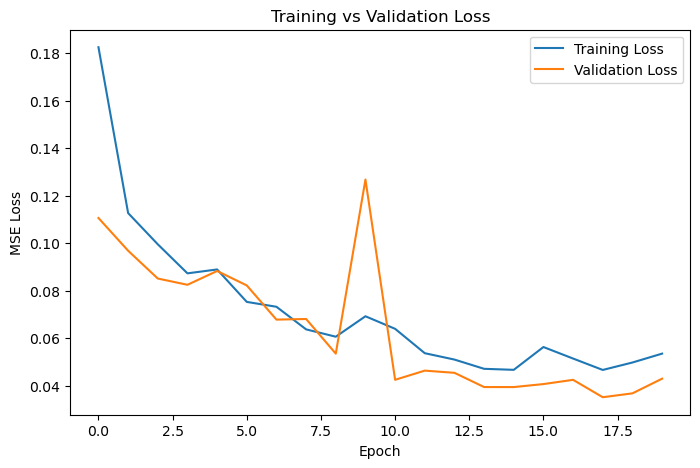

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [28]:
print("Mean MSE:", mse.mean())
print("Std MSE:", mse.std())
print("Threshold:", threshold)

Mean MSE: 0.03853951000865616
Std MSE: 0.21985098908516157
Threshold: 0.6980924772641409


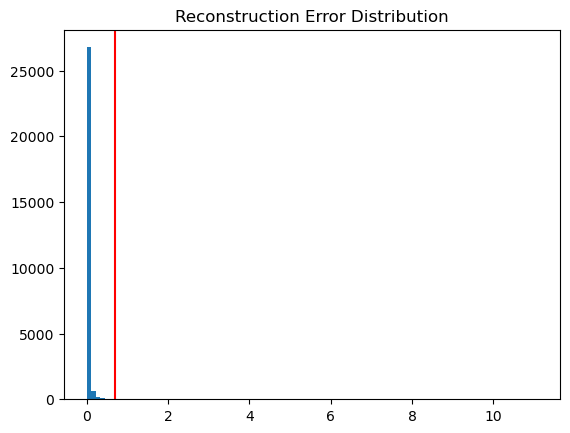

In [29]:
import matplotlib.pyplot as plt

plt.hist(mse, bins=100)
plt.axvline(threshold, color='r')
plt.title("Reconstruction Error Distribution")
plt.show()
